In [1]:
import pandas as pd
import joblib

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/raw/Crop_recommendation.csv")

model = joblib.load("../models/crop_model.pkl")
scaler = joblib.load("../models/scaler.pkl")
encoder = joblib.load("../models/label_encoder.pkl")

In [3]:
X = df.drop("label", axis=1)

y = encoder.transform(df["label"])


X_scaled = scaler.transform(X)

In [4]:
predictions = model.predict(X_scaled)

accuracy = accuracy_score(
    y,
    predictions
)

print(
    "Model Accuracy:",
    accuracy
)

Model Accuracy: 0.9990909090909091


In [5]:
print(
    classification_report(
        y,
        predictions,
        target_names=encoder.classes_
    )
)

              precision    recall  f1-score   support

       apple       1.00      1.00      1.00       100
      banana       1.00      1.00      1.00       100
   blackgram       1.00      0.99      0.99       100
    chickpea       1.00      1.00      1.00       100
     coconut       1.00      1.00      1.00       100
      coffee       1.00      1.00      1.00       100
      cotton       1.00      1.00      1.00       100
      grapes       1.00      1.00      1.00       100
        jute       0.99      1.00      1.00       100
 kidneybeans       1.00      1.00      1.00       100
      lentil       1.00      1.00      1.00       100
       maize       0.99      1.00      1.00       100
       mango       1.00      1.00      1.00       100
   mothbeans       1.00      1.00      1.00       100
    mungbean       1.00      1.00      1.00       100
   muskmelon       1.00      1.00      1.00       100
      orange       1.00      1.00      1.00       100
      papaya       1.00    

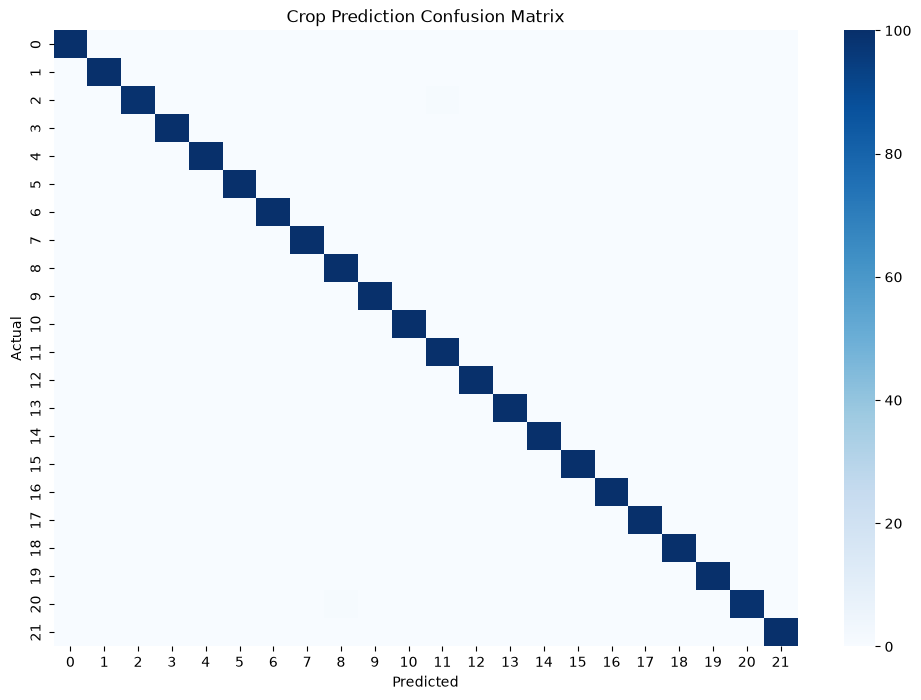

In [6]:
cm = confusion_matrix(
    y,
    predictions
)


plt.figure(figsize=(12,8))

sns.heatmap(
    cm,
    cmap="Blues"
)

plt.title("Crop Prediction Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()